<h1 align="center">
B Term research notes
</h1>

1. A term recap .............................................................................................................................................................................................





# 1. Recap

In investigatng the connection between dynamical systems and MLPs the main use case of interest so far has been denoising Auto encoders applied to MNST images with gaussian noise applied. The larger topics covered so far in the resesarch of this MQP as well as relevant research from the Paffenroth research group includes:
1. RNNs are just discrete time dynamical systems and can be represented by a blockwise matrix of functions(Hershy et. al).
2. Technically all MLPs are discretions of Euler steps applied to a vector of n dimensions where n is the max width of the network layers.(MQP generated)
3. 

## MNIST Use Case
We start with the basic use case of applying denoising auto encoders to MNIST images with gaussian noise applied. This is a useful example to focus on because denosing pressents intuitively as an interative process. Imagine a denoising auto encoder that is good but not perfect. After being fed a "noisy" MNIST image of a 4, the output should look like a clearer image of the digit. In this case the DNAE takes in a noisy image and returns a less noisy one. The dynamical systems theory comes from taking the DNAEs output and feeding it back into the DNAE as input. Could it be the case that this would produce and even clearer image of the digit? 

### data prep


In [38]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)


We then wrap MNIST in a NoisyMNIST class so that every time we sample an image from the MNIST data set we get a clean noisy pair, with the noisy image generated at time we retrive the sample. We add pixel-wise random noise drawn from normal distribition with mean 0 and standard deviation sigma

In [39]:
class NoisyMNIST(Dataset):
    def __init__(self, mnist_dataset, noise_factor=0.01):
        self.mnist = mnist_dataset
        self.noise_factor = noise_factor

    def __len__(self):
        return len(self.mnist)
    
    def add_noise(self, img, sigma =.23):
        """
        Add zero-mean Gaussian noise to an MNIST image tensor in [0, 1].
        
        Args:
            img (torch.Tensor): Input image tensor, shape (C, H, W), values in [0, 1].
            sigma (float): Standard deviation of the Gaussian noise.
        
        Returns:
            torch.Tensor: Noisy image, same shape, clamped to [0, 1].
        """
        # Generate zero-mean Gaussian noise
        noise = torch.randn_like(img) * sigma
        
        # Add noise symmetrically (can brighten or darken)
        noisy = img + noise
        # Clamp to valid range
        noisy = torch.clamp(noisy, 0., 1.)
        return noisy
    

    def __getitem__(self, idx):
        # y = clean image (target)
        y, label = self.mnist[idx]
        # x = noisy image (input)
        x = self.add_noise(y, sigma=self.noise_factor)
        return x, y  # return noisy-clean pair

We will set up dataloaders for the training and testing data respectively. Here we render one sample for a sainity check that the nois is being applied correctly.

torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])


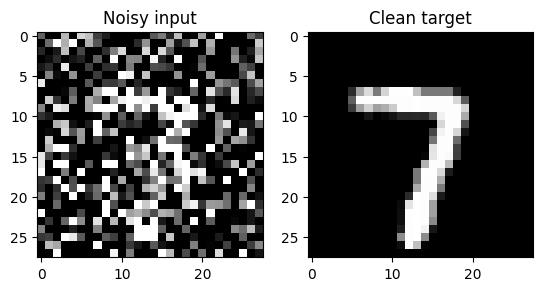

In [60]:
batch_size = 128

train_loader = DataLoader(
    NoisyMNIST(train_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    NoisyMNIST(test_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=False
)

x, y = next(iter(train_loader))
print(x.shape, y.shape)
# -> torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])

import matplotlib.pyplot as plt
plt.subplot(1,2,1)
plt.title("Noisy input")
plt.imshow(x[0][0].detach().cpu(), cmap="gray")
plt.subplot(1,2,2)
plt.title("Clean target")
plt.imshow(y[0][0].detach().cpu(), cmap="gray")
plt.show()

## Baseline DNAE Performace
While our goal is to apply, understand, and potentially iterative denoising to these images, we first must get a frame of reference. 
In order to do so we will construct a traditional DNAE and see it's general performance on this task, without doing any special dynamical systems tricks.


In [61]:
import torch.nn as nn
import numpy as np
class DAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

Using device: mps
Epoch [1/10]  Train Loss: 0.0606  Val Loss: 0.0410
Epoch [2/10]  Train Loss: 0.0363  Val Loss: 0.0319
Epoch [3/10]  Train Loss: 0.0305  Val Loss: 0.0283
Epoch [4/10]  Train Loss: 0.0275  Val Loss: 0.0259
Epoch [5/10]  Train Loss: 0.0254  Val Loss: 0.0242
Epoch [6/10]  Train Loss: 0.0239  Val Loss: 0.0230
Epoch [7/10]  Train Loss: 0.0228  Val Loss: 0.0221
Epoch [8/10]  Train Loss: 0.0219  Val Loss: 0.0212
Epoch [9/10]  Train Loss: 0.0213  Val Loss: 0.0207
Epoch [10/10]  Train Loss: 0.0207  Val Loss: 0.0202


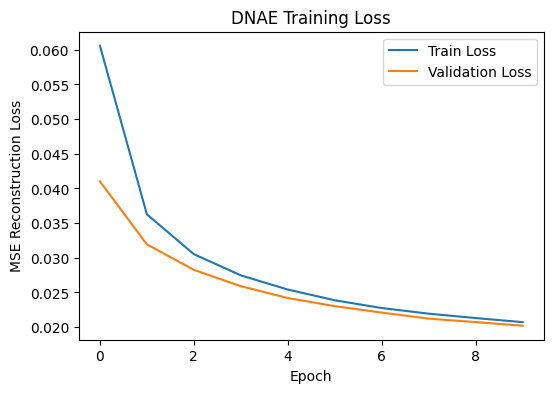

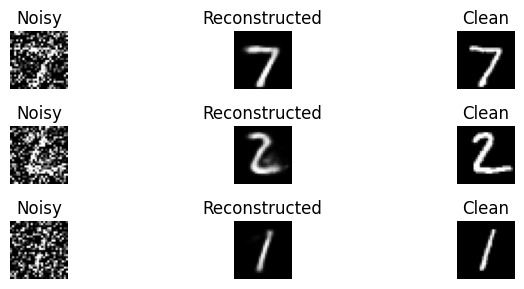

In [63]:
# --------------------------
# Training setup
# --------------------------
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")          # Apple GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = DAE().to(device)

criterion = nn.MSELoss()  # reconstruction loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Optional quick logic to set #epochs adaptively:
# (fewer if small dataset or on CPU)
if device.type == "cuda":
    num_epochs = 10
else:
    num_epochs = 10

train_losses = []
val_losses = []

# --------------------------
# Training loop
# --------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x_noisy, x_clean in train_loader:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

        optimizer.zero_grad()
        outputs = model(x_noisy)
        loss = criterion(outputs, x_clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_noisy.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_noisy, x_clean in test_loader:
            x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
            outputs = model(x_noisy)
            loss = criterion(outputs, x_clean)
            val_loss += loss.item() * x_noisy.size(0)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Early stopping logic (quick and simple):
    if epoch > 1 and abs(val_losses[-1] - val_losses[-2]) < 1e-5:
        print("Validation loss plateaued — stopping early.")
        break

# --------------------------
# Plot reconstruction loss
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("DNAE Training Loss")
plt.legend()
plt.show()

# --------------------------
# Visualize reconstruction on test set
# --------------------------
model.eval()
x_noisy, x_clean = next(iter(test_loader))
x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
with torch.no_grad():
    recon = model(x_noisy)

plt.figure(figsize=(8,3))
for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(x_noisy[i][0].cpu(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(recon[i][0].cpu(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(x_clean[i][0].cpu(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Simpler Architecture

Even with large amounts of noise applied this architecture eliminates almost all noise after a single pass. In order to investigate the efficacy of stacking, we will impliment a weaker model such that some non-trivial amount of noise remains after a single pass.

Using device: mps
Epoch [1/10]  Train Loss: 0.0657  Val Loss: 0.0522
Epoch [2/10]  Train Loss: 0.0433  Val Loss: 0.0370
Epoch [3/10]  Train Loss: 0.0353  Val Loss: 0.0330
Epoch [4/10]  Train Loss: 0.0322  Val Loss: 0.0306
Epoch [5/10]  Train Loss: 0.0300  Val Loss: 0.0289
Epoch [6/10]  Train Loss: 0.0287  Val Loss: 0.0276
Epoch [7/10]  Train Loss: 0.0276  Val Loss: 0.0266
Epoch [8/10]  Train Loss: 0.0268  Val Loss: 0.0259
Epoch [9/10]  Train Loss: 0.0260  Val Loss: 0.0252
Epoch [10/10]  Train Loss: 0.0254  Val Loss: 0.0247


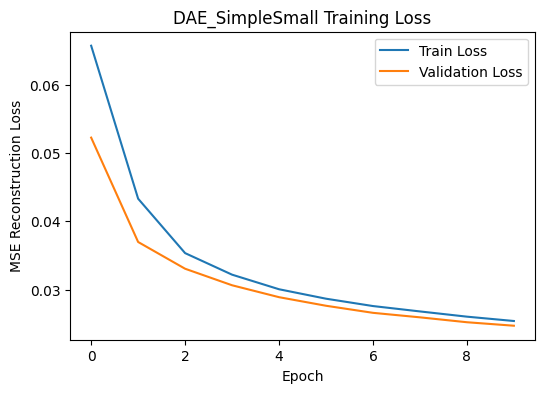

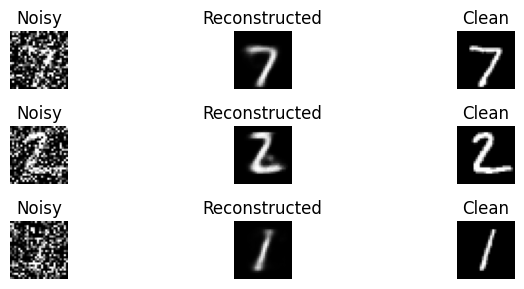

In [70]:


class DAE_SimpleSmall(nn.Module):
    """
    Simpler, smaller-capacity DAE for MNIST.
    Uses only Linear + ReLU + Sigmoid; no dropout/BN/skips.
    """
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, latent_dim)      # linear bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)
# --------------------------
# Training setup
# --------------------------
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")          # Apple GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = DAE_SimpleSmall(latent_dim=16).to(device)

criterion = nn.MSELoss()  # reconstruction loss (good for Gaussian noise)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Keep epochs logic as-is (adjust if you want)
num_epochs = 10

train_losses = []
val_losses = []

# --------------------------
# Training loop
# --------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x_noisy, x_clean in train_loader:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

        optimizer.zero_grad()
        outputs = model(x_noisy)
        loss = criterion(outputs, x_clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_noisy.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_noisy, x_clean in test_loader:
            x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
            outputs = model(x_noisy)
            loss = criterion(outputs, x_clean)
            val_loss += loss.item() * x_noisy.size(0)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Simple early stopping on plateau
    if epoch > 1 and abs(val_losses[-1] - val_losses[-2]) < 1e-5:
        print("Validation loss plateaued — stopping early.")
        break

# --------------------------
# Plot reconstruction loss
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("DAE_SimpleSmall Training Loss")
plt.legend()
plt.show()

# --------------------------
# Visualize reconstruction on test set
# --------------------------
model.eval()
x_noisy, x_clean = next(iter(test_loader))
x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
with torch.no_grad():
    recon = model(x_noisy)

plt.figure(figsize=(8,3))
for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(x_noisy[i][0].cpu(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(recon[i][0].cpu(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(x_clean[i][0].cpu(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Iterating a Vanila DNAE
Now we will turn this DNAE into an iterative map by feeding it's output back in as input. To start we will do everything the same as far as setting up the De-noising auto encoder, but at the testing stage we will simply refeed the outputs back in as inputs. 

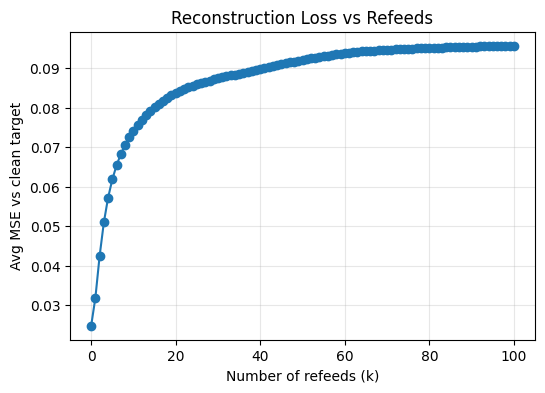

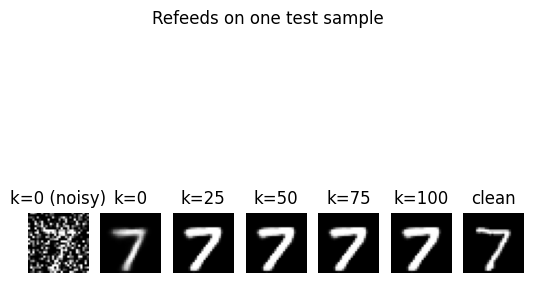

In [ ]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_refeeds(model, loader, criterion, num_refeeds=5, device="cpu"):
    """
    Compute average reconstruction loss on the test set after k refeeds.
    k = 0 uses the noisy input once (no refed passes).
    k = 1 means model(model(x_noisy)), etc.
    Returns: list of length num_refeeds+1 with average loss at each k.
    """
    model.eval()
    losses_by_k = [0.0 for _ in range(num_refeeds + 1)]
    count = 0

    for x_noisy, x_clean in loader:
        x_noisy = x_noisy.to(device)
        x_clean = x_clean.to(device)

        # k = 0 (single pass on noisy input)
        xk = x_noisy.clone()
        for k in range(num_refeeds + 1):
            # one forward pass at current state
            out = model(xk)
            # measure loss against clean target
            loss = criterion(out, x_clean)
            losses_by_k[k] += loss.item() * x_noisy.size(0)

            # prepare next refeed input (model output fed back)
            xk = out

        count += x_noisy.size(0)#add the number of samples processed in this batch from the test_loader

    # average over dataset
    losses_by_k = [L / count for L in losses_by_k]
    return losses_by_k

# -------------------------------------------------------
# Run it and plot (assumes model, test_loader, device, criterion exist)
# -------------------------------------------------------
num_refeeds = 100  # adjust as you like
refeed_losses = evaluate_refeeds(model, test_loader, criterion, num_refeeds=num_refeeds, device=device)

plt.figure(figsize=(6,4))
plt.plot(range(num_refeeds + 1), refeed_losses, marker="o")
plt.xlabel("Number of refeeds (k)")
plt.ylabel("Avg MSE vs clean target")
plt.title("Reconstruction Loss vs Refeeds")
plt.grid(True, alpha=0.3)
plt.show()

@torch.no_grad()
def visualize_refeeds(model, loader, device="cpu", num_refeeds=5, idx=0):
    model.eval()
    x_noisy, x_clean = next(iter(loader))
    x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

    xk = x_noisy.clone()
    imgs = [x_noisy[idx:idx+1]]
    split_points = [round(i * num_refeeds / 4) for i in range(5)]
    split_points.insert(0, 1)
    for k in range(1, num_refeeds + 1):
        xk = model(xk)
        if k in split_points:
            imgs.append(xk[idx:idx+1])

    # Finally append the clean target for comparison
    imgs.append(x_clean[idx:idx+1])
    titles = [f"k={k}" for k in split_points]
    titles[0] = "intial noisy"
    titles.append("clean")

    for i, (img, title) in enumerate(zip(imgs, titles)):
        plt.subplot(1, len(imgs), i + 1)
        plt.imshow(img[0,0].cpu(), cmap="gray")
        plt.title(title)
        plt.axis("off")
    plt.suptitle("Refeeds on one test sample")
    plt.show()

# Example:
visualize_refeeds(model, test_loader, device=device, num_refeeds=num_refeeds, idx=0)

## Iterative Map Based Analysis

### Defining the system created

We have now created an iterative map. Our model is a denosing autoencoder $f_\theta(x)$ where $f_\theta:\mathbb{R}^n \to \mathbb{R}^n$.

Given a noisy input $x_0$, the model outputs a version with less noise $x_1 = f_\theta(x_0)$.

By feeding the output back into the model as input we define the discrete time dynamical system $x_{(t+1)} = f_\theta(x_t)$.

$t$ is the time step or iteration index, and the model defines the evolution rule of the system. 

### Interperting The Iterative Denoising Test

In testing each noise image $x_0^{(i)}$ acts as the intial condition of the system and the starting point of a trajectory. 

Through repeated refeeding we compute the trajectory $x_0^{(i)}\to x_1^{(i)}\to x_2^{(i)}\to ... \to x_K^{(i)}$ for each intial image $i$.

### Dynamical systems characteristics

#### Fixed points

Definition: A point $x^* \in \mathbb{R}^n$ is a fixed point of a map $f$ if $f(x)=x$

Interpritation: A fixed point is an image that the DNAE reproduces exactly: $f_\theta(x) = x$. 
- This means the model sees the image as already clean. 
- Ideally these points will correspond to the clean MNIST images so refeeds don't become worse. 
- These points for a well trained DNAE would, perhaps represent clena data manifold images or ideal MNIST images. What are ideal MNIST images?

#### Attractors

Definition: An attractor A is a set of points taht satisfies: 

1. Invariance: $f(A) = A$
2. Attraction: There exists a neighborhood $U(A)$(The basin of attraction) such that for any $x_0 \in U(A),\lim_{t \to \inf} dist(f^{(t)}(X_0), A) = 0$.



## Conducting Dynamical systems tests

Now that we have framed our iterative denoiser as an iterative map, the benifit comes from our application of dynamical systems analyses to better understand how the models transformations shape the trajectory of the state over time. With this in mind we will run a seires of tests to look for characteristics of iterative maps present in our system.

## 1. Simple Attractors Test

In the results above we see that it appears repeated refeeds converge to singular images and do not continue to transform the image. Based on this it makes the most sense to check for convergence in our system. Essentially, when we refeed the image of a 7 over and over, is there some attractor 7 to which the system will converge? 

Each intial dirty image represents the starting point of a trajectory for our deterministic iterative map. We use the term fixed points, but in practice it makes sense to allow for some small tolerance of differences between $x_k$ and $x_{k+1}$. We will call this $\epsilon$. To find said stopping point we want to find the earliest point in the trajectory for which all following points remain within $\epsilon$ of.

Formally we are searching for some point $i$ such that:

$$
\forall j > i, \qquad \|x_{j}-x_{i}\| < \epsilon
$$

A naive approach would be to generate and store the full trajectories, and for each of them calculate the difference between each point in them and all following points, looking for a point where all following points are within $\epsilon$ difference. This has a worst case $O(T^2)$ complexity where $T$ is the total time or number of steps we generate. Instead we can use an applicaiton of triangle inequality to get a much simpler measure of movement between points. 
$$
\|x_{j}-x_{i}\| \leq \sum_{k=i}^{j-1} \|x_k - x_{k+1}\|
$$

As a result we can say
$$
\sum_{k=i}^{T-1}\|x_k - x_{k+1}\| < \epsilon \Rightarrow \|x_i - x_T\| < \epsilon
$$
With this definition we can calculate the stepwise differences between the images in the trajectories, and simply look for the first point for which the tail sum of differences is less that $\epsilon$. The code segments below implement fucntionality to do just that.

**note:** Our definition is a strict one, and $$\sum_{k=i}^{T-1} \|x_{k} - x_{k+1}\| > \epsilon \not\Rightarrow \|x_T - x_i\| > \epsilon$$


In [ ]:
from tqdm import tqdm
def find_halt(steps, eps):
    hlt_indx = len(steps)
    suffix_sum = 0
    for i in range(len(steps)-1, -1, -1):
        suffix_sum += steps[i]
        if suffix_sum <= eps:
            hlt_indx = i
        else:
            break

    return hlt_indx

@torch.no_grad()
def find_attractor_indicies_batch(model, loader, num_steps, eps_state, device="cpu"):
    """
    For each sample in the loader, unroll num_steps refeeds and compute
    the earliest index where the tail sum of step sizes <= eps_state.

    Returns:
      all_halt_indices: list of length total_num_samples,
                        each an int in [0, num_steps] (or num_steps if only x_T is safe).
    """
    model.eval()
    all_halt_indices = []
    for x_noisy, _ in tqdm(loader, desc="Processing batches"):
            x_noisy = x_noisy.to(device)
            batch_size = x_noisy.size(0)

            xk = x_noisy
            step_sizes_batch = []

            for _ in range(num_steps):
                x_next = model(xk)
                diff = x_next - xk

                d_batch = torch.norm(diff.view(batch_size, -1), p=2, dim=1)
                step_sizes_batch.append(d_batch.unsqueeze(1))

                xk = x_next

            step_sizes_batch = torch.cat(step_sizes_batch, dim=1)

            for b in range(batch_size):
                d_row = step_sizes_batch[b].tolist()
                halt_idx = find_halt(d_row, eps_state)
                all_halt_indices.append(halt_idx)

    return all_halt_indices
                    

#### 1.2 Determining $\epsilon$

Now it becomes important to ensure our choice of $\epsilon$ corresponds to a meaningful resolution of the state space. We are looking for atractors as we iteratively denoise a single digit. One way to describe a potential attractor is to imagine that for any 7 we iteratively denoise, there exists a single "true seven" attractor to which all 7's converge over time. A resolution that then would seem to make sense would be the intra class average nearest neighbors distance. This gives us the spatial resolution threshold that generally coressponds to one example of a digit vs another. 

In [ ]:
import torchvision
import torchvision.transforms as transforms
# -------------------------------------------------------
# Compute epsilon based on average nearest-neighbor distance
# within each digit class in the MNIST test set
# -------------------------------------------------------
@torch.no_grad()
def compute_epsilon_from_nn_test(device="cpu"):
    

    # Load clean MNIST TEST set with labels
    transform = transforms.Compose([transforms.ToTensor()])
    clean_test = torchvision.datasets.MNIST(
        root=".", train=False, download=True, transform=transform
    )

    # Group flattened clean images by class
    class_groups = {k: [] for k in range(10)}
    for img, label in clean_test:
        img = img.to(device)
        class_groups[label].append(img.view(-1))  # flatten to 784 dims

    # Compute per-class average nearest-neighbor distances
    avg_nn_dists = {}

    for digit in range(10):
        X = torch.stack(class_groups[digit])   # [n_c, 784]
        n_c = X.size(0)

        # Full pairwise distance matrix for this class
        dist_matrix = torch.cdist(X, X, p=2)   # [n_c, n_c]
        dist_matrix.fill_diagonal_(float("inf"))

        # For each sample, find nearest same-class sample
        nn_dists, _ = dist_matrix.min(dim=1)

        # Average NN distance for this digit
        avg_nn_dists[digit] = nn_dists.mean().item()

    # Global epsilon = average over all classes
    epsilon_state = sum(avg_nn_dists.values()) / 10.0

    return avg_nn_dists, epsilon_state


# Run and print results
avg_nn_dists, epsilon_state = compute_epsilon_from_nn_test(device=device)

print("\nAverage nearest-neighbor distance per digit class:")
for d in range(10):
    print(f"Digit {d}: {avg_nn_dists[d]:.5f}")

print("\nFinal epsilon_state (mean of class NN radii):", epsilon_state)


Average nearest-neighbor distance per digit class:
Digit 0: 4.89065
Digit 1: 2.16429
Digit 2: 5.57780
Digit 3: 5.26922
Digit 4: 4.77385
Digit 5: 5.32689
Digit 6: 4.72230
Digit 7: 4.13368
Digit 8: 5.53710
Digit 9: 4.38774

Final epsilon_state (mean of class NN radii): 4.6783514499664305


### 1.3 Trial 1
We can know run a first trial to try and identify if attractors exist in our system. We will achieve this my generating trajectories over 1000 time steps for each image in the MNIST test set. Based on our strict halting definintion, if over a significant portion of T, the tail sum is less than $\epsilon$, we can safely say the trajectory has moved less than $\epsilon$ away from our halting point i, since in any case where each step is not moving in a direction optimized to increase distance from $x_{(halt)}$ the actual value for $\|x_{(T)} - x_{halt}\|$. We will not consider extreamly short tails for stopping points since a tail sum less than $\epsilon$ over only 2 time steps clearly has less evidence for being an attractor than one that converges for 500. We will set a cut off for the final 10% of the trajectory, such that any trajectory not converged after 90% of T will not necessarily be considered convergent by our definintion. 

Generating 10000 trajectories


Processing batches: 100%|██████████| 79/79 [00:04<00:00, 18.49it/s]


Fraction converged before k=40.0: 0.9435
latest convergence =39
average convergence point=11.286486486486487


Processing batches: 100%|██████████| 79/79 [00:06<00:00, 12.47it/s]


Fraction converged before k=80.0: 0.9684
latest convergence =79
average convergence point=17.526022304832715


...

Fraction converged before k=240.0: 1.0000
latest convergence =131
average convergence point=20.1734


Processing batches: 100%|██████████| 79/79 [00:24<00:00,  3.26it/s]


Fraction converged before k=400.0: 1.0000
latest convergence =128
average convergence point=20.3163


Processing batches: 100%|██████████| 79/79 [00:46<00:00,  1.69it/s]

Fraction converged before k=800.0: 1.0000
latest convergence =133
average convergence point=20.3032


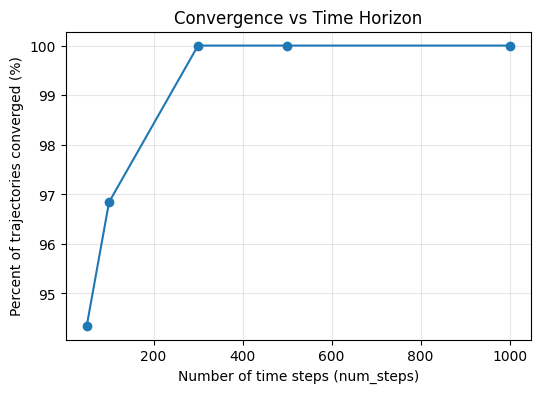

In [ ]:
def test_halting(step_list, tolerance, loader):
# Different trajectory lengths (time horizons) to test
    
    converged_fracs = []

    print("Generating 10000 trajectories")
    for num_steps in step_list:
        #print(f"\nRunning trajectories with num_steps = {num_steps}...")
        all_halt_indices = find_attractor_indicies_batch(
            model,
            loader,
            num_steps=num_steps,
            eps_state=epsilon_state,
            device=device,
        )

        halt_arr = np.array(all_halt_indices)
        total_samples = halt_arr.shape[0]

        # Require that the halt index occurs at least 10 steps before the end
        # i.e., the trajectory stays in the ε-ball for the last 10 steps
        cutoff = num_steps*.8
        converged_mask = halt_arr < cutoff
        num_converged = converged_mask.sum()
        frac_converged = num_converged / total_samples

        converged_fracs.append(frac_converged)

        #print(f"Total trajectories: {total_samples}")
        #print(f"Converged before k={cutoff}: {num_converged}")
        print(f"Fraction converged before k={cutoff}: {frac_converged:.4f}")
        print(f"latest convergence ={max(halt_arr[converged_mask])}")
        print(f"average convergence point={sum(halt_arr[converged_mask])/sum(converged_mask)}")

    # ---- Plot fraction converged vs num_steps ----
    plt.figure(figsize=(6,4))
    plt.plot(step_list, np.array(converged_fracs) * 100.0, marker="o")
    plt.xlabel("Number of time steps (num_steps)")
    plt.ylabel("Percent of trajectories converged (%)")
    plt.title("Convergence vs Time Horizon")
    plt.grid(True, alpha=0.3)
    plt.show()
step_list = [50,100, 300, 500, 1000]
loader = test_loader
test_halting(step_list=step_list, tolerance=epsilon_state, loader=test_loader)


### 1.4 Intial analysis
This result is interesting and compelling for several reasons. The main reason this result is surprising is that even if there truely are attractors in our system that all trajectories converge to, our stict definition would likely still push the tail sum over our threshold over time. Despite this, we see all trajectories at the 1000 step trial converge in less than 150 time steps, meaning the sum of all 850 single step movements following was less than the average nearest neighbor distance between digits of the same class. 

## 2.0 Fixed Point Test

In [99]:
@torch.no_grad()
def find_fixed_pts(model, loader, num_steps, device="cpu"):
    """
    For each sample in the loader, unroll up to num_steps refeeds and find
    the earliest step k where model(x_k) == x_k (true fixed point in float32).

    Returns:
      all_fp_indices: list of length total_num_samples
        - each entry is in [0, num_steps-1] if a fixed point was found
        - or -1 if no fixed point was reached within num_steps
    """
    model.eval()
    all_fp_indices = []

    for x_noisy, _ in tqdm(loader, desc="Processing batches"):
        xk = x_noisy.to(device)
        batch_size = xk.size(0)

        # -1 means "no fixed point seen yet" for that sample
        fp_idx_batch = torch.full(
            (batch_size,), -1, device=device, dtype=torch.int64
        )

        for step in range(num_steps):
            x_next = model(xk)
            diff = x_next - xk

            # L2 == 0  <=>  all pixels identical
            # you could also use diff.view(B, -1).abs().max(dim=1).values == 0
            d_batch = torch.norm(diff.view(batch_size, -1), p=2, dim=1)

            newly_fixed = (fp_idx_batch == -1) & (d_batch == 0.0)
            fp_idx_batch[newly_fixed] = step

            xk = x_next

            # Optional speedup: if every sample in this batch has found a fixed point, stop early
            if torch.all(fp_idx_batch != -1):
                break

        all_fp_indices.extend(fp_idx_batch.cpu().tolist())

    return all_fp_indices

num_steps = 600
print(torch.backends.mps.is_available())
model = model.to(device)
device = torch.device("mps")
fp_indices = find_fixed_pts(model, test_loader, num_steps=1000, device=device)
fp_arr = np.array(fp_indices)
total = fp_arr.shape[0]

num_fixed = np.sum(fp_arr != -1)
frac_fixed = num_fixed / total

print(f"Total trajectories: {total}")
print(f"Trajectories with at least one zero step: {num_fixed}")
print(f"Fraction with true fixed point: {frac_fixed:.4f}")


True


Processing batches: 100%|██████████| 79/79 [02:06<00:00,  1.60s/it]

Total trajectories: 10000
Trajectories with at least one zero step: 3
Fraction with true fixed point: 0.0003


(B) Local Stability (Jacobian/Linearization)

at any fixed point $x^*$: 

1. Compute the Jacobian $J = Df(x^*)$
2. Find its eigenvalues $\lambda_{i}$

- Stable(attracting): $|\lambda_{i} < 1$ for all $i$
- Unstable (repelling): any $|\lambda_{i}| > 1$
- Marginal: some $|\lambda_{i}| = 1$

In [ ]:
def jvp(f: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """
    Compute J_f(x) @ v (same shape as x) using autograd.
    x, v have shape (1, D). Returns (1, D).
    """
    x = x.detach().requires_grad_(True)
    y = f(x)
    assert y.shape == x.shape, "f must be R^D -> R^D (pointwise denoiser)."
    dot = (y * v).sum()
    (grad_x,) = torch.autograd.grad(dot, x, retain_graph=True, create_graph=False)
    return grad_x


def vjp(f: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
    """
    Compute J_f(x)^T @ u (same shape as x) using autograd.
    x, u have shape (1, D). Returns (1, D).
    """
    x = x.detach().requires_grad_(True)
    y = f(x)
    (grad_x,) = torch.autograd.grad(outputs=y, inputs=x, grad_outputs=u, retain_graph=True, create_graph=False)
    return grad_x


def spectral_norm_of_jacobian(
    f: Callable[[torch.Tensor], torch.Tensor],
    x_star: torch.Tensor,
    iters: int = 50,
    device: str = "cpu",
) -> float:
    """
    Estimate ||J_f(x*)||_2 (largest singular value) via power iteration on J^T J, without
    materializing J. If < 1, f is locally a contraction at x* (sufficient condition).
    
    """
    with torch.no_grad():
        x = x_star.view(1, -1).to(device)

    u = torch.randn_like(x)
    u = u / (u.norm() + 1e-12)

    for _ in range(iters):
        # v = (J^T J) u  ≈  J^T (J u)
        w = jvp(f, x, u)       # w = J u
        v = vjp(f, x, w)       # v = J^T w
        v_norm = v.norm() + 1e-12
        u = v / v_norm

    # Rayleigh quotient: ||J u||_2 is the singular value estimate
    Ju = jvp(f, x, u)
    return float(Ju.norm().item())
